In [ ]:

from src.agents import AgentSemiGradientSARSAv2
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

seed = 200

env = gym.make("Acrobot-v1", render_mode="None")

n_episodes = 10000

c:\Users\USUARIO\Desktop\EML\P1\emlenv\Lib\site-packages\gymnasium\envs\registration.py:728: UserWarning: WARN: The environment is being initialised with render_mode='None' that is not in the possible render_modes (['human', 'rgb_array']).
  logger.warn(


In [2]:
def plot_success_ratio(list_stats_success):
    successes = np.array(list_stats_success)

    cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)

    plt.figure(figsize=(6, 3))
    plt.plot(cumulative_ratio)
    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)
    plt.show()

def plot_episode_length(episode_lengths):
    y = np.array(episode_lengths, dtype=float)
    x = np.arange(len(y))

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, label="Steps por episodio")


    plt.title("Longitud de episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Steps")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_global_avg(list_stats):
    indices = list(range(len(list_stats)))
    plt.figure(figsize=(8, 4))
    plt.plot(indices, list_stats)
    plt.title("Media acumulada del return")
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")
    plt.grid(True)
    plt.show()

In [3]:
# 2. Instanciamos nuestro agente de Monte Carlo
agent = AgentSemiGradientSARSAv2(env, alpha=0.2, epsilon_decay=0.992)

step_display = n_episodes / 10


# ==========================================
# 3. BUCLE DE ENTRENAMIENTO (Lógica SARSA)
# ==========================================
print(f"Entrenando AgentSemiGradientSARSA en {env.spec.id}...")

for episode in tqdm(range(n_episodes)):
    state, info = env.reset(seed=seed)
    
    # IMPORTANTE: En SARSA, elegimos la primera acción ANTES del bucle
    action = agent.get_action(state)
    done = False
    
    while not done:
        # El entorno reacciona
        next_state, reward, terminated, truncated, info = env.step(action)
        
        # ACTUALIZACIÓN: agent.update en SARSA devuelve la SIGUIENTE acción (A')
        # que ya fue seleccionada usando la política epsilon-greedy dentro del método.
        next_action = agent.update(state, action, next_state, reward, terminated, truncated, info)
        
        # Transición de estado y acción
        state = next_state
        action = next_action
        
        done = terminated or truncated
        
    # Feedback en consola
    if episode % step_display == 0 and episode != 0:
        # Usamos list_stats[-1] que es la media calculada en tu clase
        print(f" | Media Reward: {agent.list_stats[-1]:.2f} | Epsilon: {agent.epsilon:.3f}")

# 2. Obtención de resultados
pesos, list_stats, episode_lengths, list_stats_success = agent.get_stats()

env.close()



Entrenando AgentSemiGradientSARSA en Acrobot-v1...


 10%|█         | 502/5000 [01:16<08:16,  9.06it/s]

 | Media Reward: -371.10 | Epsilon: 0.018


 20%|██        | 1001/5000 [02:03<05:32, 12.03it/s]

 | Media Reward: -301.67 | Epsilon: 0.010


...

 80%|████████  | 4003/5000 [05:28<00:52, 18.87it/s]

 | Media Reward: -209.02 | Epsilon: 0.010


 90%|█████████ | 4503/5000 [05:56<00:24, 20.70it/s]

 | Media Reward: -202.52 | Epsilon: 0.010


100%|██████████| 5000/5000 [06:25<00:00, 12.98it/s]


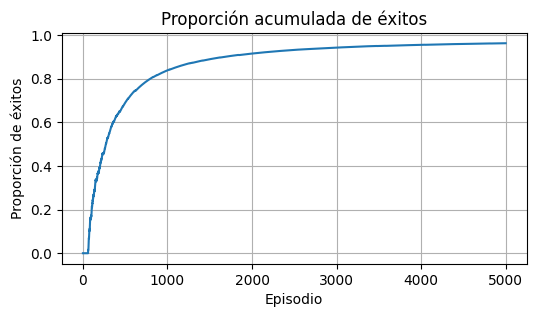

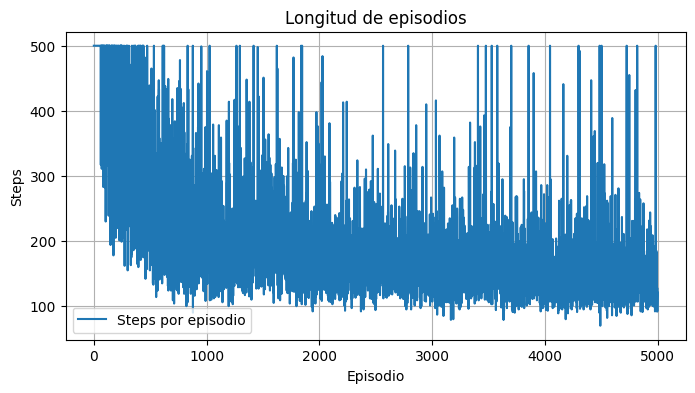

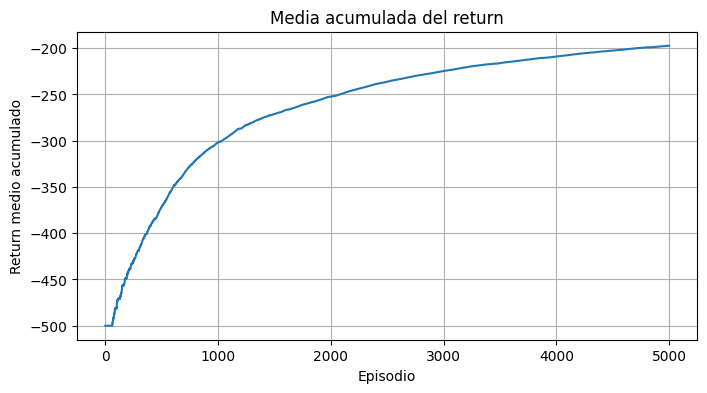

Máxima proporcion: -197.33


In [4]:
#@title Proporción de aciertos por número de episodios

plot_success_ratio(list_stats_success)

plot_episode_length(episode_lengths)

plot_global_avg(list_stats)

print(f"Máxima proporcion: {list_stats[-1]}")